<a href="https://colab.research.google.com/github/alperarslan19/spectralbridge/blob/main/03_train_spectralbridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Audio–Visual Alignment Bridges: Training and Evaluation

**Research question.** Can audio and images be aligned *directly*, using language-free
encoders (Audio-MAE + DINOv2), or is text-mediated alignment (CLAP + CLIP) the better
route? And does a frequency-aware bridge architecture (Fourier features + SIREN) help?

**Setup.** 1,269 audio–image pairs from a 16-category VGGSound subset, split 1,015
train / 254 val with a fixed seed. All four encoders are frozen; their embeddings were
pre-extracted in `02_feature_extraction.ipynb` and cached to Drive as `.npy` files —
this notebook trains and evaluates only small alignment bridges on those cached
embeddings (minutes per model on a single T4).

**Methods compared** (identical InfoNCE loss, data split, and training budget):

| Bridge | Encoder pair | Isolates |
|---|---|---|
| Linear probe (768→768) | Audio-MAE / DINOv2 | is a full-rank linear map enough? |
| ReLU MLP (768→128→128→768) | Audio-MAE / DINOv2 | same capacity as SpectralBridge, standard activations |
| SpectralBridge (Fourier 64-d + 2 SIREN layers) | Audio-MAE / DINOv2 | the proposed frequency-aware bridge |
| CLAP→CLIP MLP (512→128→512) | CLAP / CLIP | text-mediated pair, fairly trained |
| Zero-shot CLAP→CLIP | CLAP / CLIP | text-mediated pair, no training |

**Evaluation.** Audio→image Recall@K, computed strictly on the held-out val split
(254 queries, 254-image gallery). Random chance: R@5 ≈ 1.97%.

Notebook flow: setup → architecture → data split → SpectralBridge training →
evaluation protocol → baselines → final comparison.

In [1]:
# ============================================================
# Cell 1: Setup — seeds, paths, device, cached features
# ============================================================
# All features were pre-extracted in 02_feature_extraction.ipynb
# and cached to Drive as .npy files. This notebook trains and
# evaluates alignment bridges on those cached embeddings only —
# no raw audio/image processing happens here.

from google.colab import drive
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Reproducibility ---
torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# --- Paths (single source of truth) ---
BASE_DIR = Path("/content/drive/MyDrive/spectralbridge_data")
FEATURES_DIR = BASE_DIR / "features"

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# --- Load cached features ---
audiomae_features = np.load(FEATURES_DIR / "audiomae_audio_features.npy")
dinov2_features   = np.load(FEATURES_DIR / "dinov2_image_features.npy")
clap_features     = np.load(FEATURES_DIR / "clap_audio_features.npy")
clip_features     = np.load(FEATURES_DIR / "clip_image_features.npy")
metadata = np.load(FEATURES_DIR / "feature_metadata.npy", allow_pickle=True).item()

print(f"Audio-MAE (self-supervised audio):  {audiomae_features.shape}")
print(f"DINOv2    (self-supervised vision): {dinov2_features.shape}")
print(f"CLAP      (text-aligned audio):     {clap_features.shape}")
print(f"CLIP      (text-aligned vision):    {clip_features.shape}")
print(f"Samples: {len(metadata['filenames'])}")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Audio-MAE (self-supervised audio):  (1269, 768)
DINOv2    (self-supervised vision): (1269, 768)
CLAP      (text-aligned audio):     (1269, 512)
CLIP      (text-aligned vision):    (1269, 512)
Samples: 1269


In [2]:
# ============================================================
# Cell 2: SpectralBridge architecture
# ============================================================
# Design rationale: with only ~1,000 training pairs, the bridge
# must be small and heavily regularized. Capacity is constrained
# via a 64-d Fourier bottleneck, two hidden layers of width 128,
# and dropout 0.3. Outputs are L2-normalized so that training
# (InfoNCE) and evaluation (cosine retrieval) share the same
# unit-sphere geometry.

class FourierFeatureMapping(nn.Module):
    """Random Fourier feature mapping (frozen projection).

    Projects the input through a fixed random matrix B and maps the
    result to [sin, cos] pairs, following Tancik et al. (2020).
    B is frozen: it defines a fixed sinusoidal basis, not a learned one.
    """
    def __init__(self, input_dim=768, mapping_dim=64, sigma=10.0):
        super().__init__()
        self.B = nn.Parameter(
            torch.randn(input_dim, mapping_dim) * sigma,
            requires_grad=False
        )

    def forward(self, x):
        x_proj = x @ self.B                                   # (batch, 64)
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)  # (batch, 128)


class SineActivation(nn.Module):
    """SIREN-style sine activation (Sitzmann et al., 2020)."""
    def __init__(self, w0=1.0):
        super().__init__()
        self.w0 = w0

    def forward(self, x):
        return torch.sin(self.w0 * x)


class SpectralBridge(nn.Module):
    """Frequency-aware audio-to-visual alignment bridge.

    Audio-MAE (768-d) → Fourier features (128-d) → 2 SIREN layers (128-d)
    → linear head (768-d, DINOv2 space) → L2 normalization.
    ~132K trainable parameters.
    """
    def __init__(
        self,
        audio_dim=768,        # Audio-MAE embedding dim
        visual_dim=768,       # DINOv2 embedding dim
        hidden_dim=128,
        fourier_dim=64,
        dropout=0.3,
        fourier_sigma=10.0,
        w0_initial=30.0,      # SIREN first-layer frequency (paper default)
        w0_hidden=1.0
    ):
        super().__init__()
        self.fourier = FourierFeatureMapping(audio_dim, fourier_dim, fourier_sigma)
        fourier_out = fourier_dim * 2  # sin + cos

        self.net = nn.Sequential(
            nn.Linear(fourier_out, hidden_dim),
            SineActivation(w0=w0_initial),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            SineActivation(w0=w0_hidden),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, visual_dim),  # no activation on output
        )
        self._init_weights()

    def _init_weights(self):
        """SIREN initialization scheme for stable sine-network training."""
        with torch.no_grad():
            nn.init.uniform_(self.net[0].weight, -1 / 128, 1 / 128)
            nn.init.uniform_(self.net[3].weight,
                             -np.sqrt(6 / 128), np.sqrt(6 / 128))
            nn.init.uniform_(self.net[6].weight,
                             -np.sqrt(6 / 128), np.sqrt(6 / 128))

    def forward(self, audio_emb):
        x = self.fourier(audio_emb)
        x = self.net(x)
        return F.normalize(x, dim=-1)  # unit sphere, matches cosine retrieval


# --- Sanity checks: parameter count, forward pass, output norms ---
model = SpectralBridge().to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Trainable params: {trainable:,}")
print(f"Frozen params (Fourier matrix): {frozen:,}")

test_audio = torch.randn(16, 768).to(device)
test_out = model(test_audio)
norms = test_out.norm(dim=-1)
print(f"Forward: {tuple(test_audio.shape)} -> {tuple(test_out.shape)}")
print(f"Output norms in [{norms.min():.6f}, {norms.max():.6f}] (expect ~1.0)")

del test_audio, test_out
torch.cuda.empty_cache()

Trainable params: 132,096
Frozen params (Fourier matrix): 49,152
Forward: (16, 768) -> (16, 768)
Output norms in [1.000000, 1.000000] (expect ~1.0)


In [3]:
# ============================================================
# Cell 3: Dataset and train/val split
# ============================================================
# Cached embeddings are tiny (~20 MB total), so large batches are
# free. Batch size 512 gives 511 in-batch negatives per sample,
# which directly strengthens the contrastive signal (vs. 63
# negatives at batch size 64).

class AudioVisualDataset(Dataset):
    """Paired audio/visual embeddings for contrastive training."""
    def __init__(self, audio_features, visual_features):
        self.audio = torch.FloatTensor(audio_features)
        self.visual = torch.FloatTensor(visual_features)
        assert len(self.audio) == len(self.visual), "Feature count mismatch!"

    def __len__(self):
        return len(self.audio)

    def __getitem__(self, idx):
        return self.audio[idx], self.visual[idx]


# --- 80/20 split with fixed seed (reproducible) ---
n_samples = len(audiomae_features)
n_train = int(0.8 * n_samples)

indices = np.random.RandomState(42).permutation(n_samples)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

train_audio, train_visual = audiomae_features[train_indices], dinov2_features[train_indices]
val_audio, val_visual = audiomae_features[val_indices], dinov2_features[val_indices]

# Split CLAP/CLIP features with the SAME indices, so all methods
# share one train/val partition (fair comparison, no leakage)
train_clap, train_clip = clap_features[train_indices], clip_features[train_indices]
val_clap,   val_clip   = clap_features[val_indices],   clip_features[val_indices]

print(f"Train: {len(train_indices)} samples")
print(f"Val:   {len(val_indices)} samples")

train_dataset = AudioVisualDataset(train_audio, train_visual)
val_dataset = AudioVisualDataset(val_audio, val_visual)

# --- DataLoaders ---
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True, drop_last=False)

print(f"Batch size: {batch_size} ({batch_size - 1} in-batch negatives per sample)")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# InfoNCE sanity reference: a random model scores ~log(batch_size)
print(f"Random-model InfoNCE loss reference: log({batch_size}) = {np.log(batch_size):.4f}")

Train: 1015 samples
Val:   254 samples
Batch size: 512 (511 in-batch negatives per sample)
Train batches: 2, Val batches: 1
Random-model InfoNCE loss reference: log(512) = 6.2383


Random reference — train: 6.24, val: 5.54
Epoch    1/1000 | train 6.3454 | val 5.6750 | lr 1.00e-04  <- new best
Epoch    2/1000 | train 6.3461 | val 5.6742 | lr 1.00e-04  <- new best
Epoch    3/1000 | train 6.3209 | val 5.6734 | lr 1.00e-04  <- new best
Epoch    4/1000 | train 6.2618 | val 5.6730 | lr 1.00e-04  <- new best
Epoch    5/1000 | train 6.2343 | val 5.6720 | lr 1.00e-04  <- new best
Epoch    6/1000 | train 6.2288 | val 5.6713 | lr 1.00e-04  <- new best
Epoch    7/1000 | train 6.1801 | val 5.6705 | lr 1.00e-04  <- new best
Epoch    8/1000 | train 6.1648 | val 5.6696 | lr 1.00e-04  <- new best
Epoch    9/1000 | train 6.1099 | val 5.6689 | lr 1.00e-04  <- new best
Epoch   10/1000 | train 6.1051 | val 5.6684 | lr 1.00e-04  <- new best
Epoch   11/1000 | train 6.0910 | val 5.6678 | lr 1.00e-04  <- new best
Epoch   12/1000 | train 6.0587 | val 5.6665 | lr 1.00e-04  <- new best
Epoch   13/1000 | train 6.0415 | val 5.6652 | lr 1.00e-04  <- new best
Epoch   14/1000 | train 6.0079 | va

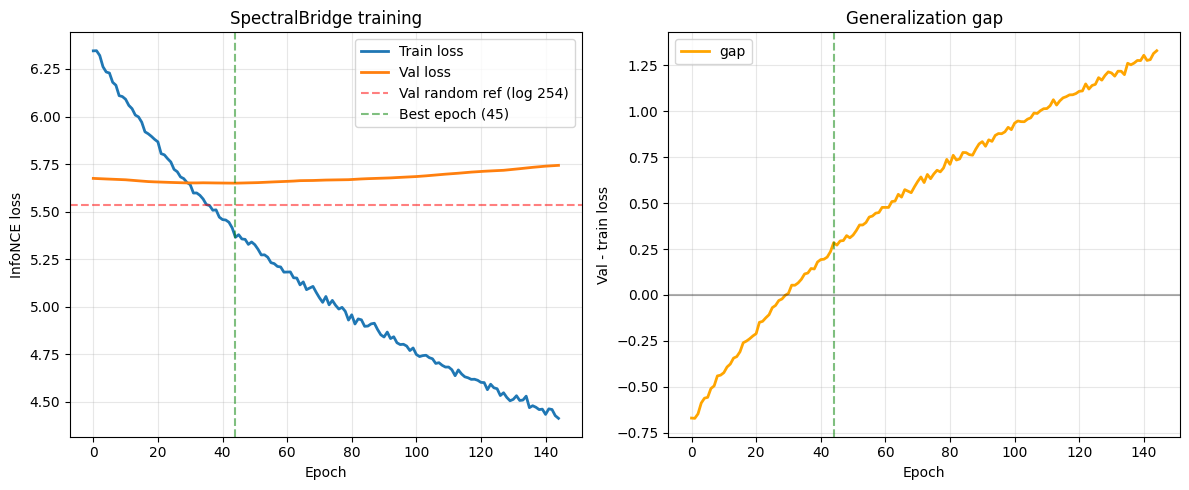

In [4]:
# ============================================================
# Cell 4: InfoNCE loss and training loop
# ============================================================
# Training choices for a small dataset (1,015 pairs):
# - "Epochs" here are tiny: 1,015 samples / 512 batch = 2 gradient
#   steps per epoch. Budgets below are scaled accordingly.
# - early stopping (patience=100 epochs ≈ 200 steps): stop when
#   val loss stalls, restore best weights
# - cosine LR annealing over the full budget, gradient clipping
#   as a guard against unstable steps

def info_nce_loss(pred_visual, true_visual, temperature=0.07):
    """InfoNCE: in-batch contrastive loss over cosine similarities.

    Each predicted embedding must identify its true visual pair among
    all N in-batch candidates. Equivalent to cross-entropy over the
    similarity matrix with diagonal labels.
    """
    batch_size = pred_visual.shape[0]

    # Model outputs are already L2-normalized; verify defensively.
    pred_norms = pred_visual.norm(dim=-1)
    assert torch.allclose(pred_norms, torch.ones_like(pred_norms), atol=1e-4), \
        "pred_visual not L2-normalized — magnitudes would leak into similarities"

    true_visual = F.normalize(true_visual, dim=-1)
    similarity_matrix = pred_visual @ true_visual.T / temperature
    labels = torch.arange(batch_size, device=pred_visual.device)
    return F.cross_entropy(similarity_matrix, labels)


def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for audio_emb, visual_emb in loader:
        audio_emb, visual_emb = audio_emb.to(device), visual_emb.to(device)
        loss = info_nce_loss(model(audio_emb), visual_emb)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = 0
    for audio_emb, visual_emb in loader:
        audio_emb, visual_emb = audio_emb.to(device), visual_emb.to(device)
        total_loss += info_nce_loss(model(audio_emb), visual_emb).item()
    return total_loss / len(loader)


# --- Hyperparameters (single source of truth) ---
lr = 1e-4
weight_decay = 0.01
n_epochs = 1000
patience = 100

# --- Initialize model, optimizer, scheduler ---
model = SpectralBridge().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)

# --- Training with early stopping ---
best_val_loss = float('inf')
no_improve = 0
best_epoch = 0
train_losses, val_losses = [], []

# Random-model reference is log(N) where N is the effective batch
# size: log(512) ≈ 6.24 for train batches, log(254) ≈ 5.54 for the
# single val batch. A model that beats neither has learned nothing.
print(f"Random reference — train: {np.log(512):.2f}, val: {np.log(254):.2f}")

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = validate(model, val_loader, device)
    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        best_epoch = epoch
        no_improve = 0
        marker = "  <- new best"
    else:
        no_improve += 1
        marker = ""

    if (epoch + 1) % 25 == 0 or epoch == 0 or no_improve == 0:
        print(f"Epoch {epoch+1:4d}/{n_epochs} | train {train_loss:.4f} | "
              f"val {val_loss:.4f} | lr {scheduler.get_last_lr()[0]:.2e}{marker}")

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1} "
              f"(no val improvement for {patience} epochs)")
        break

print(f"Best epoch: {best_epoch+1}, best val loss: {best_val_loss:.4f}")
model.load_state_dict(best_model_state)

# --- Training curves ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss', linewidth=2)
plt.plot(val_losses, label='Val loss', linewidth=2)
plt.axhline(np.log(254), color='red', linestyle='--', alpha=0.5, label='Val random ref (log 254)')
plt.axvline(best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch+1})')
plt.xlabel('Epoch'); plt.ylabel('InfoNCE loss')
plt.title('SpectralBridge training')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
gap = np.array(val_losses) - np.array(train_losses)
plt.plot(gap, color='orange', linewidth=2)
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(best_epoch, color='green', linestyle='--', alpha=0.5)
plt.xlabel('Epoch'); plt.ylabel('Val - train loss')
plt.title('Generalization gap')
plt.legend(['gap']); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Cell 5: Evaluation protocol (held-out validation set only)
# ============================================================
# All retrieval metrics are computed strictly on the val split:
# queries are the 254 val audio embeddings, the gallery is the
# 254 val images. Training samples never enter the gallery —
# an earlier version of this evaluation used all 1,269 pairs,
# which leaks training data into the gallery and inflates scores.
#
# Random-chance reference for a 254-item gallery:
#   R@K = K / 254  →  R@1 ≈ 0.39%, R@5 ≈ 1.97%, R@10 ≈ 3.94%

@torch.no_grad()
def evaluate_retrieval(audio_emb, visual_emb, bridge=None, ks=(1, 5, 10)):
    """Audio→image retrieval on a held-out set.

    audio_emb:  (N, d_a) query audio embeddings (val split ONLY)
    visual_emb: (N, d_v) gallery image embeddings (val split ONLY)
    bridge:     optional model mapping audio→visual space.
                If None, audio_emb is used directly (zero-shot CLAP→CLIP).
    """
    audio = torch.FloatTensor(audio_emb).to(device)
    gallery = F.normalize(torch.FloatTensor(visual_emb).to(device), dim=-1)

    if bridge is not None:
        bridge.eval()
        preds = bridge(audio)               # already L2-normalized
    else:
        preds = F.normalize(audio, dim=-1)  # zero-shot path

    sims = preds @ gallery.T                # (N, N) cosine similarities
    ranks = sims.argsort(dim=-1, descending=True)
    correct = torch.arange(len(audio), device=device).unsqueeze(1)

    return {f"R@{k}": 100 * (ranks[:, :k] == correct).any(dim=-1).float().mean().item()
            for k in ks}


n_val = len(val_audio)
chance = {f"R@{k}": 100 * k / n_val for k in (1, 5, 10)}
print(f"Validation gallery size: {n_val}")
print(f"Random chance: " + ", ".join(f"{m}={v:.2f}%" for m, v in chance.items()))

# --- SpectralBridge (trained, best checkpoint) ---
sb_metrics = evaluate_retrieval(val_audio, val_visual, bridge=model)
print(f"\nSpectralBridge (Audio-MAE → bridge → DINOv2):")
print("  " + ", ".join(f"{m}={v:.2f}%" for m, v in sb_metrics.items()))

# --- Zero-shot CLAP→CLIP (no training; shared text-aligned space) ---
clap_zs_metrics = evaluate_retrieval(val_clap, val_clip)
print(f"\nZero-shot CLAP→CLIP (text-mediated, no training):")
print("  " + ", ".join(f"{m}={v:.2f}%" for m, v in clap_zs_metrics.items()))

Validation gallery size: 254
Random chance: R@1=0.39%, R@5=1.97%, R@10=3.94%

SpectralBridge (Audio-MAE → bridge → DINOv2):
  R@1=0.39%, R@5=2.76%, R@10=5.91%

Zero-shot CLAP→CLIP (text-mediated, no training):
  R@1=0.79%, R@5=2.36%, R@10=5.51%


In [6]:
# ============================================================
# Cell 6: Baseline models — Linear Probe, ReLU MLP, CLAP→CLIP
# ============================================================
# Three trained baselines isolate what actually matters:
# - Linear Probe:  is a full-rank linear map enough? (no bottleneck)
# - ReLU MLP:      same capacity/bottleneck as SpectralBridge but
#                  standard activations — isolates the SIREN choice
# - CLAP→CLIP MLP: gives the text-aligned encoders a trained
#                  projection, the fairest version of that pipeline
# All use the same loss, data split, and training budget as
# SpectralBridge (Cell 4).

class LinearBaseline(nn.Module):
    """Single linear layer, 768→768. Tests whether nonlinearity
    (and the Fourier bottleneck) is needed at all."""
    def __init__(self, in_dim=768, out_dim=768):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return F.normalize(self.linear(x), dim=-1)


class ReLUBaseline(nn.Module):
    """Same depth/width/dropout as SpectralBridge, ReLU instead of
    SIREN+Fourier. Isolates the contribution of sine activations."""
    def __init__(self, in_dim=768, hidden=128, out_dim=768, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class CLAPtoCLIPBaseline(nn.Module):
    """Trained projection from CLAP audio space to CLIP image space."""
    def __init__(self, in_dim=512, hidden=128, out_dim=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def train_bridge(model, train_loader, val_loader, model_name,
                 n_epochs=1000, lr=1e-4, patience=100):
    """Identical training protocol for all bridges (cf. Cell 4)."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-6)

    best_val_loss = float('inf')
    no_improve = 0
    best_epoch = 0

    print(f"\nTraining {model_name} "
          f"({sum(p.numel() for p in model.parameters()):,} params)")

    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, device)
        val_loss = validate(model, val_loader, device)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:4d} | train {train_loss:.4f} | "
                  f"val {val_loss:.4f} | best {best_val_loss:.4f}")

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)
    print(f"  Best epoch: {best_epoch+1}, best val loss: {best_val_loss:.4f}")
    return model


# --- Train all three baselines ---
linear_model = train_bridge(
    LinearBaseline().to(device),
    train_loader, val_loader, "Linear Probe")

relu_model = train_bridge(
    ReLUBaseline().to(device),
    train_loader, val_loader, "ReLU MLP")

# CLAP→CLIP uses its own loaders (512-d features, same split indices)
clap_train_loader = DataLoader(AudioVisualDataset(train_clap, train_clip),
                               batch_size=512, shuffle=True,
                               num_workers=2, pin_memory=True)
clap_val_loader = DataLoader(AudioVisualDataset(val_clap, val_clip),
                             batch_size=512, shuffle=False,
                             num_workers=2, pin_memory=True)

clap_model = train_bridge(
    CLAPtoCLIPBaseline().to(device),
    clap_train_loader, clap_val_loader, "CLAP→CLIP Trained")

# CLAP→CLIP linear probe (512→512) — symmetric counterpart to the
# Audio-MAE/DINOv2 linear probe, so both encoder pairs are tested
# with both a linear and a nonlinear bridge.

clap_linear_model = train_bridge(
    LinearBaseline(in_dim=512, out_dim=512).to(device),
    clap_train_loader, clap_val_loader, "CLAP→CLIP Linear Probe")


Training Linear Probe (590,592 params)
  Epoch  100 | train 1.9361 | val 3.6434 | best 3.6347
  Early stopping at epoch 181
  Best epoch: 81, best val loss: 3.6347

Training ReLU MLP (214,016 params)
  Epoch  100 | train 4.5317 | val 3.9532 | best 3.9532
  Epoch  200 | train 3.9325 | val 3.7643 | best 3.7643
  Epoch  300 | train 3.6371 | val 3.7201 | best 3.7193
  Epoch  400 | train 3.3890 | val 3.6946 | best 3.6932
  Epoch  500 | train 3.2171 | val 3.6810 | best 3.6743
  Epoch  600 | train 3.1450 | val 3.6690 | best 3.6690
  Epoch  700 | train 3.0606 | val 3.6678 | best 3.6647
  Epoch  800 | train 3.0051 | val 3.6654 | best 3.6637
  Epoch  900 | train 2.9780 | val 3.6658 | best 3.6630
  Early stopping at epoch 925
  Best epoch: 825, best val loss: 3.6630

Training CLAP→CLIP Trained (131,712 params)
  Epoch  100 | train 4.5252 | val 3.8602 | best 3.8602
  Epoch  200 | train 4.0667 | val 3.6701 | best 3.6701
  Epoch  300 | train 3.8155 | val 3.6141 | best 3.6141
  Epoch  400 | train 3.

Audio→image retrieval, held-out val set (254 pairs)

             Method           Encoders  Params   R@1   R@5  R@10
       Linear Probe Audio-MAE / DINOv2 590,592 17.32 45.67 62.20
   CLAP→CLIP Linear        CLAP / CLIP 262,656 13.39 37.80 61.02
  CLAP→CLIP Trained        CLAP / CLIP 131,712 14.96 36.22 57.87
           ReLU MLP Audio-MAE / DINOv2 214,016 11.81 34.25 56.30
     SpectralBridge Audio-MAE / DINOv2 132,096  0.39  2.76  5.91
Zero-shot CLAP→CLIP        CLAP / CLIP       0  0.79  2.36  5.51
      Random chance                  —       —  0.39  1.97  3.94


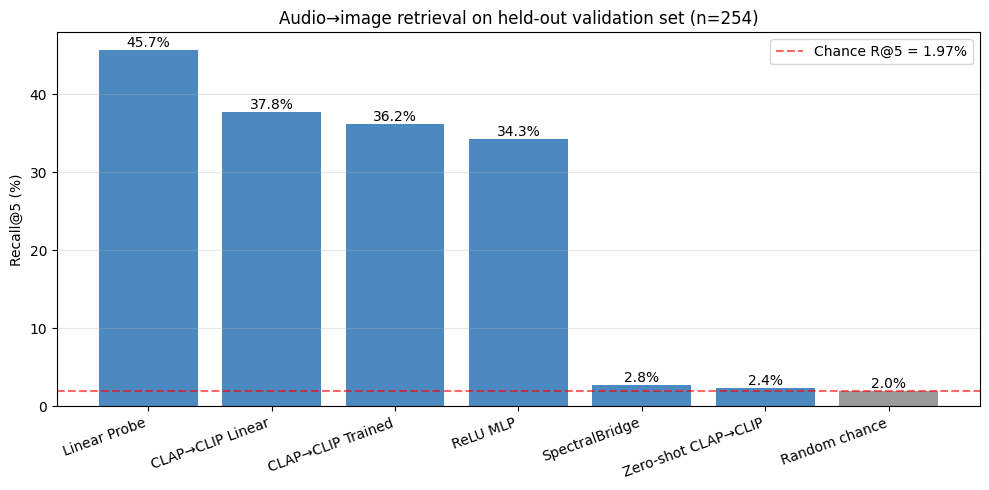

In [7]:
# ============================================================
# Cell 7: Final comparison — all methods, held-out val set
# ============================================================
import pandas as pd

results = {
    "Random chance":        {f"R@{k}": 100 * k / n_val for k in (1, 5, 10)},
    "Zero-shot CLAP→CLIP":  clap_zs_metrics,
    "CLAP→CLIP Trained":    evaluate_retrieval(val_clap, val_clip, bridge=clap_model),
    "CLAP→CLIP Linear":     evaluate_retrieval(val_clap, val_clip, bridge=clap_linear_model),
    "ReLU MLP":             evaluate_retrieval(val_audio, val_visual, bridge=relu_model),
    "Linear Probe":         evaluate_retrieval(val_audio, val_visual, bridge=linear_model),
    "SpectralBridge":       sb_metrics,
}

param_counts = {
    "Random chance": "—",
    "Zero-shot CLAP→CLIP": "0",
    "CLAP→CLIP Trained": f"{sum(p.numel() for p in clap_model.parameters()):,}",
    "CLAP→CLIP Linear": f"{sum(p.numel() for p in clap_linear_model.parameters()):,}",
    "ReLU MLP": f"{sum(p.numel() for p in relu_model.parameters()):,}",
    "Linear Probe": f"{sum(p.numel() for p in linear_model.parameters()):,}",
    "SpectralBridge": f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
}

encoder_pairs = {
    "Random chance": "—",
    "Zero-shot CLAP→CLIP": "CLAP / CLIP",
    "CLAP→CLIP Trained": "CLAP / CLIP",
    "CLAP→CLIP Linear": "CLAP / CLIP",
    "ReLU MLP": "Audio-MAE / DINOv2",
    "Linear Probe": "Audio-MAE / DINOv2",
    "SpectralBridge": "Audio-MAE / DINOv2",
}

df = pd.DataFrame([
    {"Method": m, "Encoders": encoder_pairs[m], "Params": param_counts[m], **vals}
    for m, vals in results.items()
]).sort_values("R@5", ascending=False)

print(f"Audio→image retrieval, held-out val set ({n_val} pairs)\n")
print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# --- Bar chart: R@5 across methods ---
plt.figure(figsize=(10, 5))
methods = df["Method"].tolist()
r5 = df["R@5"].tolist()
colors = ['#888' if m == "Random chance" else '#2E75B6' for m in methods]
bars = plt.bar(methods, r5, color=colors, alpha=0.85)
plt.axhline(100 * 5 / n_val, color='red', linestyle='--', alpha=0.6,
            label=f'Chance R@5 = {100*5/n_val:.2f}%')
for bar, v in zip(bars, r5):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:.1f}%",
             ha='center', va='bottom', fontsize=10)
plt.ylabel('Recall@5 (%)')
plt.title(f'Audio→image retrieval on held-out validation set (n={n_val})')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

**1. The simplest bridge wins.** Across both encoder pairs, a plain linear (or shallow
MLP) bridge matches or beats anything more elaborate. For Audio-MAE/DINOv2 a single
768×768 linear map reaches 45.7% R@5 (chance: 2.0%) and beats the same-capacity
nonlinear MLP (34.3%). Two encoders trained independently, on different modalities,
with no shared supervision, align to a large degree under a simple affine transform.

**2. Neither encoder family is clearly superior — the small gap depends on the bridge.**
With a linear bridge the language-free pair leads (45.7% vs 37.8% R@5); with an MLP
bridge the text-mediated pair edges ahead (36.2% vs 34.3%). Both gaps are modest, so
"language-free aligns better" is not supported once the comparison is made symmetric
(both pairs tested with both bridge types).

**3. The proposed Fourier+SIREN bridge fails, and the failure is isolated to that
block.** The same-capacity ReLU MLP generalizes well (34.3% R@5); SpectralBridge
performs at chance level (2.8% R@5). The only difference between them is the frozen
random Fourier projection + sine activations. Hypothesized mechanism (untested): these
components were designed for low-dimensional coordinate inputs, not 768-d embeddings —
the frozen random 768→64 projection discards information a learned compression would
keep, and the σ=10 / w0=30 settings are calibrated for coordinate scales.

**4. Text-aligned encoders transfer poorly zero-shot but adapt cheaply.** Zero-shot
CLAP→CLIP is at chance (2.4% R@5); a small trained projection lifts it to 36–38% —
competitive with the language-free pair.

**Methodological note.** Two flaws in earlier versions were identified and corrected:
evaluation leakage (training samples in the retrieval gallery, inflating scores for
memorizing models) and under-training (2-gradient-step epochs made a 100-epoch budget
≈ 35 steps; an apparent 7.6× gap between encoder pairs was largely an under-training
artifact, and the pairs are roughly on par under a proper budget).

**Limitation and future work.** With 16 categories (~16 val samples each), this
evaluation cannot distinguish category-level alignment from instance-level alignment.
Next steps: within-category retrieval (gallery restricted to one category), and probing
embeddings for continuous physical factors (e.g., wind intensity). See README for the
full discussion.